In [28]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from benchmark.examples.gaussian.comparison.comparison import Comparison
from benchmark.examples.gaussian.comparison.plot import Plot
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0_M1  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
datasets_normal_10_M1 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
datasets_student_M1   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")

datasets_normal_0_M2  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_normal_0.pkl")
datasets_normal_10_M2 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_normal_10.pkl")
datasets_student_M2 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/02datasets_student_df10.pkl")

datasets_normal_0_M3  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_0.pkl")
datasets_normal_10_M3 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_normal_10.pkl")
datasets_student_M3 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/03datasets_student_df10.pkl")

datasets_normal_0_direct  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_normal_0.pkl")
datasets_normal_10_direct = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_normal_10.pkl")
datasets_student_direct   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_student_df10.pkl")



In [29]:
evidence_n0=Comparison.evidence_extract(datasets_normal_0_M1)
evidence_n0=Comparison.add_evidence(evidence_n0,datasets_normal_0_M2,"M2")
evidence_n0=Comparison.add_evidence(evidence_n0,datasets_normal_0_M3,"M3")
evidence_n0=Comparison.BF_calculator(evidence_n0)
evidence_n0=Comparison.prob_calculator(evidence_n0)
direct_df_0=pd.DataFrame(datasets_normal_0_direct)
evidence_n0 = evidence_n0.merge(
    direct_df_0[["id","pred_model","logBF_12_direct","logBF_13_direct","logBF_23_direct"]],
    on="id", how="left"
)

In [32]:
evidence_n10=Comparison.evidence_extract(datasets_normal_10_M1)
evidence_n10=Comparison.add_evidence(evidence_n10,datasets_normal_10_M2,"M2")
evidence_n10=Comparison.add_evidence(evidence_n10,datasets_normal_10_M3,"M3")
evidence_n10=Comparison.BF_calculator(evidence_n10)
evidence_n10=Comparison.prob_calculator(evidence_n10)
direct_df_10=pd.DataFrame(datasets_normal_10_direct)
evidence_n10=evidence_n10.merge(
    direct_df_10[["id","pred_model","logBF_12_direct","logBF_13_direct","logBF_23_direct"]],
    on="id", how="left"
)

In [33]:
evidence_t=Comparison.evidence_extract(datasets_student_M1)
evidence_t=Comparison.add_evidence(evidence_t,datasets_student_M2,"M2")
evidence_t=Comparison.add_evidence(evidence_t,datasets_student_M3,"M3")
evidence_t=Comparison.BF_calculator(evidence_t)
evidence_t=Comparison.prob_calculator(evidence_t)
direct_df_t=pd.DataFrame(datasets_student_direct)
evidence_t=evidence_t.merge(
    direct_df_t[["id","pred_model","logBF_12_direct","logBF_13_direct","logBF_23_direct"]],
    on="id", how="left"
)

In [5]:
# print(evidence_t.columns)

In [6]:
# print(evidence_n0["pred_model"])

In [21]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold"
})

pair method          MAE    Median_AE
  12    NPE 37384.950977 23216.191852
  12 Direct   232.901057   234.401456
  13    NPE     0.026088     0.023190
  13 Direct    16.225181    13.597612
  23    NPE 37384.949541 23216.181485
  23 Direct   261.356104   261.543963


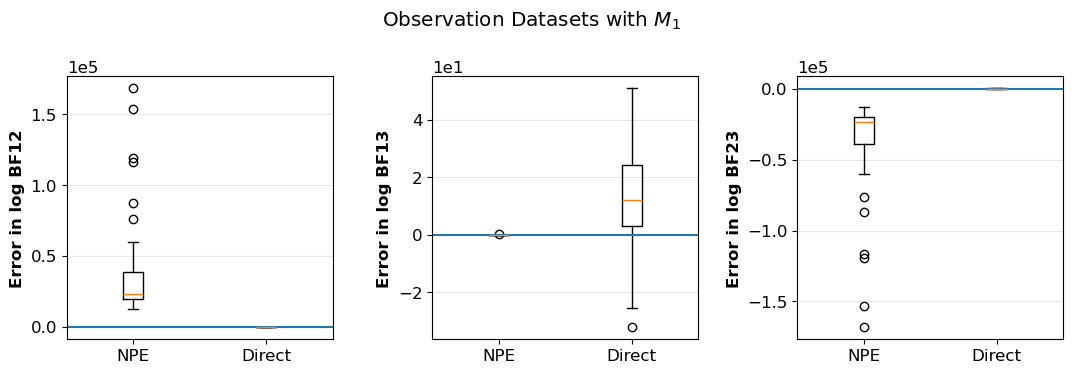

In [34]:
df_err, summary = Plot.plot(evidence_n0,title=r"Observation Datasets with $M_1$")

pair method          MAE    Median_AE
  12    NPE 11441.033169 11044.056233
  12 Direct   231.363768   231.757602
  13    NPE  8346.369309  7999.974161
  13 Direct    37.617097    31.166470
  23    NPE  3094.663860  3089.116564
  23 Direct   266.831220   273.455697


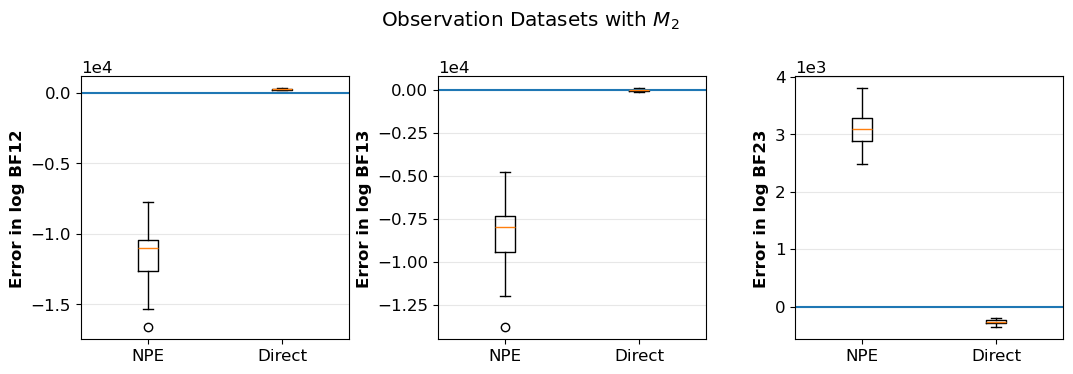

In [23]:
df_err, summary = Plot.plot(evidence_n10,title=r"Observation Datasets with $M_2$ ")

pair method          MAE    Median_AE
  12    NPE 30800.211437 23658.091669
  12 Direct   233.835848   231.992770
  13    NPE     0.025814     0.019868
  13 Direct    24.205623    20.533812
  23    NPE 30800.212678 23658.121059
  23 Direct   265.116617   262.086700


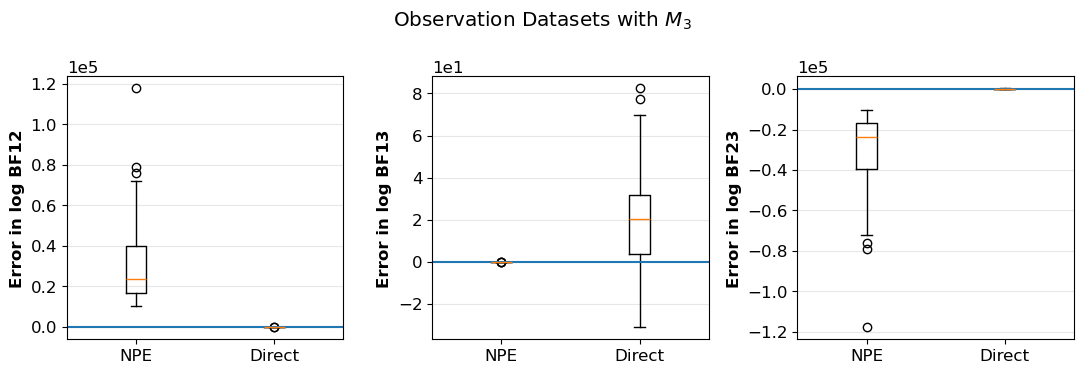

In [24]:
df_err, summary = Plot.plot(evidence_t,title=r"Observation Datasets with $M_3$")

In [ ]:
print("n0_gold_BF12",evidence_n0["logBF_12_gold"].mean().round(4),"n0_gold_BF13",evidence_n0["logBF_13_gold"].mean().round(4))
print("n0_npe_BF12",evidence_n0["logBF_12_npe"].mean().round(4),"n0_npe_BF13",evidence_n0["logBF_13_npe"].mean().round(4))
print("n0_direct_BF12",evidence_n0["logBF_12_direct"].mean().round(4),"n0_direct_BF13",evidence_n0["logBF_13_direct"].mean().round(4))

In [35]:
print("n10_gold",evidence_n10["p_gold"].mean().round(4))
print("n10_npe",evidence_n10["p_npe"].mean().round(4))
print("n10_direct",evidence_n10["pred_model"].mean().round(4))

n10_gold [0. 1. 0.]
n10_npe [0. 1. 0.]
n10_direct [0. 1. 0.]


In [36]:
print("t_gold",evidence_t["p_gold"].mean().round(4))
print("t_npe",evidence_t["p_npe"].mean().round(4))
print("t_direct",evidence_t["pred_model"].mean().round(4))

t_gold [0.3733 0.     0.6267]
t_npe [0.3737 0.     0.6263]
t_direct [0.1489 0.     0.8511]


In [37]:
print("n0_gold",evidence_n0["p_gold"].mean().round(4))
print("n0_npe",evidence_n0["p_npe"].mean().round(4))
print("n0_direct",evidence_n0["pred_model"].mean().round(4))

n0_gold [0.633 0.    0.367]
n0_npe [0.6332 0.     0.3668]
n0_direct [0.8573 0.     0.1427]


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def col_to_matrix(df: pd.DataFrame, col: str) -> np.ndarray:
    mats = []
    for i, v in enumerate(df[col].tolist()):
        arr = np.asarray(v, dtype=float).reshape(-1)
        if arr.size != 3:
            raise ValueError(f"Row {i} in column '{col}' has size {arr.size}, expected 3.")
        mats.append(arr)
    mat = np.vstack(mats)
    row_sums = mat.sum(axis=1)
    if np.max(np.abs(row_sums - 1.0)) > 1e-3:
        print(f"[WARN] Column '{col}' row sums not close to 1.")
    return mat

def compute_l1_distances(evidence_df: pd.DataFrame,
                         title:str,
                         col_gold="p_gold",
                         col_npe="p_npe",
                         col_direct="pred_model",
                         ):

    P_gold = col_to_matrix(evidence_df, col_gold)
    P_npe  = col_to_matrix(evidence_df, col_npe)
    P_dir  = col_to_matrix(evidence_df, col_direct)

    # L1(p,q) = sum_k |p_k - q_k|
    L1_npe = np.sum(np.abs(P_npe - P_gold), axis=1)
    L1_dir = np.sum(np.abs(P_dir - P_gold), axis=1)

    df_out = evidence_df.copy()
    df_out["L1_npe_vs_gold"] = L1_npe
    df_out["L1_dir_vs_gold"] = L1_dir

    summary = pd.DataFrame({
        "method": ["NPE", "Direct"],
        "mean_L1": [L1_npe.mean(), L1_dir.mean()],
        "median_L1": [np.median(L1_npe), np.median(L1_dir)],
        "std_L1": [L1_npe.std(), L1_dir.std()],
        "min_L1": [L1_npe.min(), L1_dir.min()],
        "max_L1": [L1_npe.max(), L1_dir.max()],
    })

    print(summary.to_string(index=False))
    
    plt.figure(figsize=(6,4))
    plt.boxplot([L1_npe, L1_dir], labels=["NPE vs Gold", "Direct vs Gold"])
    plt.ylabel("L1 distance")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

    return summary, df_out


In [ ]:
summary_l1, evidence_with_l1 = compute_l1_distances(evidence_n0,
                                                    title="Normal_0: L1 distance to Gold posterior probability")

In [ ]:
summary_l1, evidence_with_l1 = compute_l1_distances(evidence_n10,
                                                    title="Normal_10: L1 distance to Gold posterior probability")

In [ ]:
summary_l1, evidence_with_l1 = compute_l1_distances(evidence_t,
                                                    title="Student_t: L1 distance to Gold posterior probability")

In [14]:
import plotly.express as px
df_gold   = pd.DataFrame(np.vstack(evidence_n0["p_gold"]), columns=["p1","p2","p3"])
df_npe    = pd.DataFrame(np.vstack(evidence_n0["p_npe"]), columns=["p1","p2","p3"])
df_direct = pd.DataFrame(np.vstack(evidence_n0["pred_model"]), columns=["p1","p2","p3"])
df_gold["method"] = "Gold"
df_npe["method"] = "NPE"
df_direct["method"] = "Direct"

df = pd.concat([df_gold, df_npe,df_direct], ignore_index=True)
# edge_df = df[df["p2"] < 0.02]
fig = px.scatter_ternary(df, a="p1", b="p2", c="p3", color="method", symbol="method")
fig.update_traces(marker=dict(size=10, opacity=0.6, line=dict(width=1)))
fig.show()

In [ ]:
eps = 1e-4
dfj = df.copy()
noise = np.random.normal(0, eps, size=(len(dfj), 3))
dfj[["p1","p2","p3"]] = (dfj[["p1","p2","p3"]].values + noise).clip(0, 1)
dfj[["p1","p2","p3"]] = dfj[["p1","p2","p3"]] / dfj[["p1","p2","p3"]].sum(axis=1).values[:,None]

fig = px.scatter_ternary(dfj, a="p1", b="p2", c="p3", color="method", symbol="method")
fig.update_traces(marker=dict(size=10, opacity=0.6, line=dict(width=1)))
fig.show()

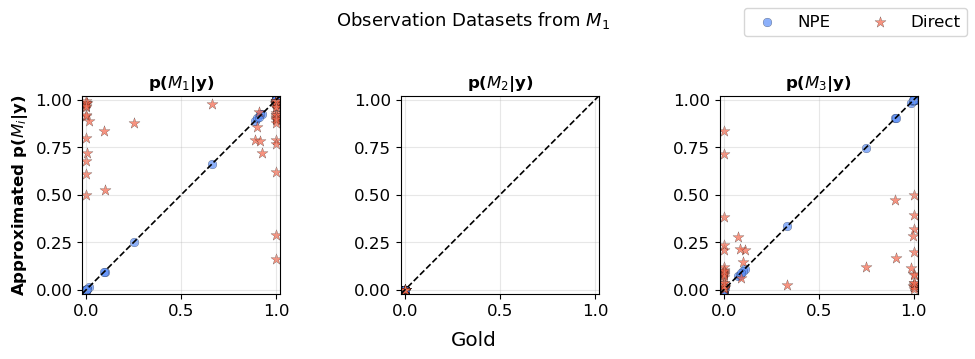

In [39]:
# plt.rcParams.update({
#     "font.size": 12,
#     "axes.titlesize": 12,
#     "axes.titleweight": "bold",
#     "axes.labelsize": 12,
#     "axes.labelweight": "bold"
# })
df_gold   = pd.DataFrame(np.vstack(evidence_n0["p_gold"]), columns=["p1","p2","p3"])
df_npe    = pd.DataFrame(np.vstack(evidence_n0["p_npe"]), columns=["p1","p2","p3"])
df_direct = pd.DataFrame(np.vstack(evidence_n0["pred_model"]), columns=["p1","p2","p3"])
Pg = df_gold[["p1","p2","p3"]].to_numpy()
Pn = df_npe [["p1","p2","p3"]].to_numpy()
Pd = df_direct [["p1","p2","p3"]].to_numpy()

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))

labels = [r"p($M_1$|y)", r"p($M_2$|y)", r"p($M_3$|y)"]

for j in range(3):
    x = Pg[:, j]
    y_n = Pn[:, j]
    y_d = Pd[:, j]

    lo = np.min([-0.02, y_n.min(), y_d.min()])
    hi = np.max([1.02, y_n.max(), y_d.max()])

    # y=x
    ax[j].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)

    # NPE
    ax[j].scatter(
        x, y_n,
        s=40,
        alpha=0.7,
        marker="o",
        color="#5B8FF9",
        edgecolors="k",
        linewidths=0.2,
        label="NPE"
    )

    # Direct
    ax[j].scatter(
        x, y_d,
        s=70,
        alpha=0.7,
        marker="*",
        color="#F4664A",
        edgecolors="k",
        linewidths=0.2,
        label="Direct"
    )

    ax[j].set_xlim(lo, hi)
    ax[j].set_ylim(lo, hi)
    ax[j].set_aspect("equal", adjustable="box")
    ax[j].grid(True, alpha=0.3)

    ax[j].set_title(f"{labels[j]}")
    if j == 0:
        ax[j].set_ylabel(r"Approximated p($M_i$|y)")

handles, labels_leg = ax[0].get_legend_handles_labels()
fig.supxlabel("Gold", y=0.01)
fig.legend(handles, labels_leg, loc="upper right", ncol=2, frameon=True)
fig.suptitle(r"Observation Datasets from $M_1$", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

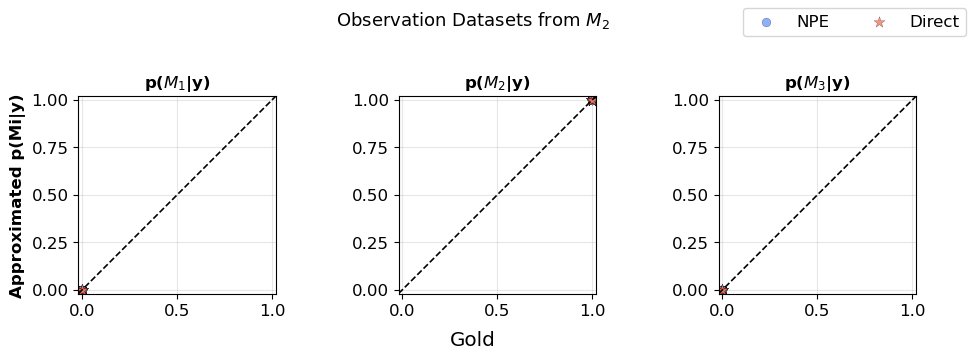

In [40]:
df_gold   = pd.DataFrame(np.vstack(evidence_n10["p_gold"]), columns=["p1","p2","p3"])
df_npe    = pd.DataFrame(np.vstack(evidence_n10["p_npe"]), columns=["p1","p2","p3"])
df_direct = pd.DataFrame(np.vstack(evidence_n10["pred_model"]), columns=["p1","p2","p3"])
Pg = df_gold[["p1","p2","p3"]].to_numpy()
Pn = df_npe [["p1","p2","p3"]].to_numpy()
Pd = df_direct [["p1","p2","p3"]].to_numpy()

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))

labels = [r"p($M_1$|y)", r"p($M_2$|y)", r"p($M_3$|y)"]

for j in range(3):
    x = Pg[:, j]
    y_n = Pn[:, j]
    y_d = Pd[:, j]

    lo = np.min([-0.02, y_n.min(), y_d.min()])
    hi = np.max([1.02, y_n.max(), y_d.max()])

    # y=x
    ax[j].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)

    # NPE
    ax[j].scatter(
        x, y_n,
        s=40,
        alpha=0.7,
        marker="o",
        color="#5B8FF9",
        edgecolors="k",
        linewidths=0.2,
        label="NPE"
    )

    # Direct
    ax[j].scatter(
        x, y_d,
        s=70,
        alpha=0.7,
        marker="*",
        color="#F4664A",
        edgecolors="k",
        linewidths=0.2,
        label="Direct"
    )

    ax[j].set_xlim(lo, hi)
    ax[j].set_ylim(lo, hi)
    ax[j].set_aspect("equal", adjustable="box")
    ax[j].grid(True, alpha=0.3)

    ax[j].set_title(f"{labels[j]}")
    if j == 0:
        ax[j].set_ylabel("Approximated p(Mi|y)")

handles, labels_leg = ax[0].get_legend_handles_labels()
fig.supxlabel("Gold", y=0.01)
fig.legend(handles, labels_leg, loc="upper right", ncol=2, frameon=True)
fig.suptitle(r"Observation Datasets from $M_2$", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

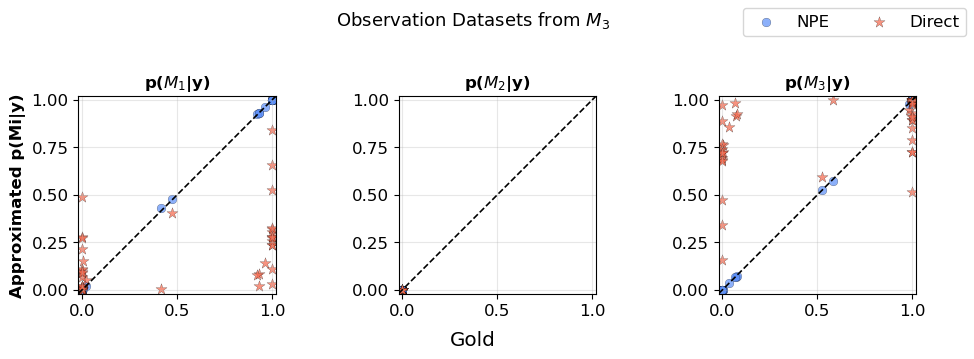

In [41]:
df_gold   = pd.DataFrame(np.vstack(evidence_t["p_gold"]), columns=["p1","p2","p3"])
df_npe    = pd.DataFrame(np.vstack(evidence_t["p_npe"]), columns=["p1","p2","p3"])
df_direct = pd.DataFrame(np.vstack(evidence_t["pred_model"]), columns=["p1","p2","p3"])
Pg = df_gold[["p1","p2","p3"]].to_numpy()
Pn = df_npe [["p1","p2","p3"]].to_numpy()
Pd = df_direct [["p1","p2","p3"]].to_numpy()

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))

labels = [r"p($M_1$|y)", r"p($M_2$|y)", r"p($M_3$|y)"]

for j in range(3):
    x = Pg[:, j]
    y_n = Pn[:, j]
    y_d = Pd[:, j]

    lo = np.min([-0.02, y_n.min(), y_d.min()])
    hi = np.max([1.02, y_n.max(), y_d.max()])

    # y=x
    ax[j].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)

    # NPE
    ax[j].scatter(
        x, y_n,
        s=40,
        alpha=0.7,
        marker="o",
        color="#5B8FF9",
        edgecolors="k",
        linewidths=0.2,
        label="NPE"
    )

    # Direct
    ax[j].scatter(
        x, y_d,
        s=70,
        alpha=0.7,
        marker="*",
        color="#F4664A",
        edgecolors="k",
        linewidths=0.2,
        label="Direct"
    )

    ax[j].set_xlim(lo, hi)
    ax[j].set_ylim(lo, hi)
    ax[j].set_aspect("equal", adjustable="box")
    ax[j].grid(True, alpha=0.3)

    ax[j].set_title(f"{labels[j]}")
    if j == 0:
        ax[j].set_ylabel("Approximated p(Mi|y)")

handles, labels_leg = ax[0].get_legend_handles_labels()
fig.supxlabel("Gold", y=0.01)
fig.legend(handles, labels_leg, loc="upper right", ncol=2, frameon=True)
fig.suptitle(r"Observation Datasets from $M_3$", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()